## Supplementary Figure 3

Note: This notebook requires the following simulation outputs (see `simulations.md` for run commands):

- `out/supp_fig3_ee_ii/`: networks with E-E and I-I connections, 5 seeds

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import sys
from functools import partial
from pathlib import Path

import numpy as np
import jax
import jax.numpy as jnp
from diffrax import diffeqsolve, ODETerm, SaveAt, Euler, ConstantStepSize

import matplotlib as mpl
import matplotlib.pyplot as plt
import spiffyplots
from spiffyplots import MultiPanel
from matplotlib.colors import to_rgba
from cmcrameri import cm as cmc

mpl.style.use('spiffy')
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",})
mpl.rc('text.latex', preamble=r'\usepackage{cmbright}')

from bcp.analysis import HydraRunOutput, HydraMultirun, rebuild_traj_run

repo_root = next(d for d in [Path.cwd(), *Path.cwd().parents] if (d / "bcp").is_dir())
sys.path.insert(0, str(repo_root))
from run_traj import SimulationRunner

#### Directory setup

In [2]:
run_dir = repo_root / "out" / "supp_fig3_ee_ii"
shapes_dir = repo_root / "data" / "shapes"

sfig3_dir = repo_root / "figures" / "supp_fig3"
sfig3_dir.mkdir(parents=True, exist_ok=True)

#### Plotting parameters

In [3]:
cm = 1 / 2.54

singlecolwidth = 8.5 * cm
onehalfcolwidth = 11.4 * cm
doublecolwidth = 17.4 * cm

color_exc = '#CD2027'
color_inh = '#0077B8'
color_inh_ff = '#57CAF1'
color_inputs = '#808285'
color_openloop = 'gray'
color_closedloop = '#F49F1E'
color_target = 'black'
color_accent = 'black'
color_shading = 'gray'

linewidth = 1.0

### Panels b-d: training performance

In [4]:
figsize_perf = (11*cm, 3.5*cm)
xticks_time = [0, 180, 360]

In [5]:
runs = HydraMultirun(run_dir, result_files=['results.pkl'])
table = runs.table(keys=['OL_R2', 'CL_error', 'OL_loss', 'training_time'])
X_TRAINING = table['training_time'][0]

R2 = np.stack(table['OL_R2'])
FB = np.abs(np.stack(table['CL_error'])).mean(-1)
LOSS = np.stack(table['OL_loss'])

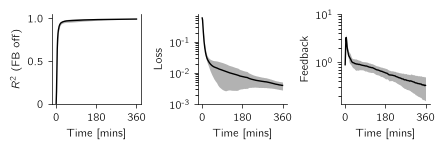

In [6]:
fig = MultiPanel(grid=[3], figsize=figsize_perf, width_ratios=[1, 1, 1])

ax = fig.panels[0]
ax.plot(X_TRAINING, R2.mean(0), color='black', lw=linewidth)
ax.fill_between(X_TRAINING, R2.mean(0) - R2.std(0), R2.mean(0) + R2.std(0), color='black', alpha=0.3, linewidth=0)
ax.set_ylim(1e-1, 1.05)
ax.spines['right'].set_visible(True)
ax.set_ylabel(r'$R^2$ (FB off)', fontsize=8)
ax.set_yticks([0, 0.5, 1.0])
ax.set_yticklabels([0, 0.5, 1.0])

ax = fig.panels[1]
ax.plot(X_TRAINING, LOSS.mean(0), color='black', lw=linewidth)
ax.fill_between(X_TRAINING, LOSS.mean(0) - LOSS.std(0), LOSS.mean(0) + LOSS.std(0), color='black', alpha=0.3, linewidth=0)
ax.set_ylabel(r'Loss', fontsize=8)
ax.set_yscale('log')
ax.set_yticks([1e-3, 1e-2, 1e-1])
ax.set_yticklabels([r'10\textsuperscript{-3}', r'10\textsuperscript{-2}', r'10\textsuperscript{-1}'])

ax = fig.panels[2]
ax.plot(X_TRAINING, FB.mean(0), color='black', lw=linewidth)
ax.fill_between(X_TRAINING, FB.mean(0) - FB.std(0), FB.mean(0) + FB.std(0), color='black', alpha=0.3, linewidth=0)
ax.set_ylabel(r'Feedback', fontsize=8)
ax.set_yscale('log')
ax.set_yticks([1e0, 1e1])
ax.set_yticklabels([r'10\textsuperscript{0}', r'10\textsuperscript{1}'])

for ax in fig.panels:
    ax.set_xlabel('Time [mins]')
    ax.set_xticks(xticks_time)
    ax.set_xticklabels(xticks_time)

plt.savefig(sfig3_dir / 'b-d_performance.pdf', bbox_inches='tight')
plt.show()

### Panel e: output trajectory after learning

In [7]:
EXAMPLE_SEED = 1
figsize_traj = (2*cm, 2*cm)

In [8]:
example_run = HydraRunOutput(run_dir / f"seed{EXAMPLE_SEED}")
cfg, task, vectorfield = rebuild_traj_run(example_run, shapes_dir)
final_state = example_run.load_pickle('final_state.pkl')
sim = SimulationRunner(vectorfield, Euler(), ConstantStepSize(), cfg.dt, cfg.rec_dt, cfg.T)

# one trajectory of burn-in, then closed- and open-loop evaluation on the next
x, y, x_interp, y_interp = task.simulate()
eval_state, _ = sim(dict(final_state), x_interp)
x, y, x_interp, y_interp = task.simulate()

_, CL_sol = sim.closedloop(eval_state, x_interp, y_interp)
CL_results = vectorfield.analyze_run(x, CL_sol, cfg.dt, cfg.rec_dt, y, closedloop=True,
                                     W_IE_override=eval_state['W_IE'])
_, OL_sol = sim(eval_state, x_interp)
OL_results = vectorfield.analyze_run(x, OL_sol, cfg.dt, cfg.rec_dt, y, closedloop=False,
                                     W_IE_override=eval_state['W_IE'])
target_traj = task.target.get_trajectory()

/Users/julian/research/balance-controlled-plasticity/data/shapes/turtle.svg


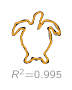

In [9]:
fig, ax = plt.subplots(1, 1, figsize=figsize_traj)

ax.plot(OL_results['uOut'][:, 0], OL_results['uOut'][:, 1], color=color_openloop, lw=linewidth)
ax.plot(CL_results['uOut'][:, 0], CL_results['uOut'][:, 1], color=color_closedloop, lw=linewidth)
ax.plot(target_traj[:, 0], target_traj[:, 1], color=color_target, lw=linewidth, zorder=-1)

ax.axis('off')
ax.set_aspect('equal', adjustable='box', anchor='SE')
ax.text(0.5, -0.05, rf"$R^2$={OL_results['R2']:.3f}",
        fontsize=8, color=color_openloop, ha='center', va='top', transform=ax.transAxes)

plt.savefig(sfig3_dir / 'e_trajectory_after.pdf', bbox_inches='tight')
plt.show()

### Panel f: E-E weights during learning

In [10]:
EE_SEED = 3
figsize_ee = (4.0*cm, 3.0*cm)
ylim_ee = (1.22, 1.27)

In [11]:
g_EE_A = HydraRunOutput(run_dir / f"seed{EE_SEED}").load_pickle('results.pkl')['g_EE_A']  # [recordings, assemblies]

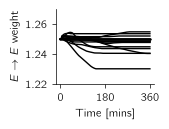

In [12]:
fig, ax = plt.subplots(figsize=figsize_ee)
ax.plot(X_TRAINING, g_EE_A, color='black', lw=1.0)

ax.set_ylabel(r'$E\rightarrow E$ weight', fontsize=8)
ax.set_xlabel('Time [mins]', fontsize=8)
ax.set_xticks(xticks_time)
ax.set_xticklabels(xticks_time)
ax.set_ylim(*ylim_ee)

plt.savefig(sfig3_dir / 'f_ee_weights.pdf', bbox_inches='tight')
plt.show()

### Panels g, h: ISN test before and after learning

In [13]:
STATIC_INPUT = 10.0
PERTURBATION = 1e-6
figsize_isn = (5.5*cm, 3*cm)
ylim_isn = (0, 0.6)

In [14]:
@jax.tree_util.register_pytree_node_class
class StaticInput:
    def __init__(self, x_static):
        self.x_static = x_static

    def evaluate(self, t):
        return self.x_static

    def tree_flatten(self):
        return (self.x_static,), None

    @classmethod
    def tree_unflatten(cls, aux_data, children):
        return cls(*children)


@partial(jax.jit, static_argnums=(0,))
def run_fixed_inhibition(vf, state, inputs, rI):
    term = ODETerm(lambda t, y, args: vf.call_fixed_inhibition(y, t, inputs, rI))
    sol = diffeqsolve(term, Euler(), t0=0, t1=cfg.T, dt0=cfg.dt, y0=state,
                      saveat=SaveAt(ts=sim.rec_ts), stepsize_controller=ConstantStepSize(),
                      max_steps=None)
    return sol


def check_ISN_regime(state, frozen):
    # equilibrium under static input, then perturb E with I frozen (or intact)
    inputs = StaticInput(jnp.ones((1, cfg.inputs.N)) * STATIC_INPUT)
    state, sol1 = sim(dict(state), inputs)
    rI = vectorfield.actI(state["uI"])
    state["uE"] = state["uE"] + PERTURBATION
    sol2 = run_fixed_inhibition(vectorfield, state, inputs, rI) if frozen else sim(state, inputs)[1]

    ts = jnp.concatenate([sol1.ts, sol2.ts + cfg.T])
    rE = vectorfield.actE(jnp.concatenate([sol1.ys["uE"], sol2.ys["uE"]]))
    return ts, rE.mean(-1)


isn = {}
for name, state in [('before', vectorfield.get_initial_state()), ('after', final_state)]:
    isn[name] = {'frozen': check_ISN_regime(state, frozen=True),
                 'intact': check_ISN_regime(state, frozen=False)}

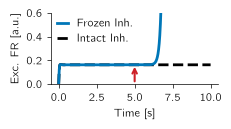

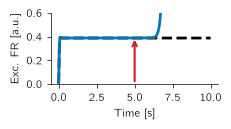

In [15]:
for name, panel, arrow_top, legend in [('before', 'g', 0.17, True), ('after', 'h', 0.4, False)]:
    fig, ax = plt.subplots(1, 1, figsize=figsize_isn)
    ax.plot(*isn[name]['frozen'], color=color_inh, lw=2, label='Frozen Inh.')
    ax.plot(*isn[name]['intact'], color='black', ls='dashed', zorder=-10, lw=2, label='Intact Inh.')

    ax.set_ylim(*ylim_isn)
    ax.set_ylabel('Exc. FR [a.u.]')
    ax.set_xlabel('Time [s]')
    ax.annotate('', xy=(cfg.T, arrow_top), xytext=(cfg.T, 0.0),
                arrowprops=dict(arrowstyle='->', color=color_exc, lw=1.5))
    if legend:
        plt.legend(handlelength=1, borderpad=0, loc='upper left')

    plt.savefig(sfig3_dir / f'{panel}_isn_{name}_learning.pdf', bbox_inches='tight')
    plt.show()